# Parsing the Logfiles

In [17]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROUND = 1
TIMESTAMP = "0416-0300"


LOG_DIR = Path(f"../logs/round_{ROUND}/{TIMESTAMP}")

# .json has round, status, profit, activitiesLog
with open(LOG_DIR / f"{TIMESTAMP}.json") as f:
    submission = json.load(f)

print(f"Round: {submission['round']}, Status: {submission['status']}, Profit: {submission['profit']}")

# Parse activitiesLog into DataFrame
from io import StringIO
activities = pd.read_csv(StringIO(submission["activitiesLog"]), sep=";")

sub_osmium = activities[activities["product"] == "ASH_COATED_OSMIUM"].copy()
sub_pepper = activities[activities["product"] == "INTARIAN_PEPPER_ROOT"].copy()

print(f"\nFinal PnL:")
for name, df in [("OSMIUM", sub_osmium), ("PEPPER", sub_pepper)]:
    last = df.groupby("day").last()["profit_and_loss"]
    print(f"  {name}: {last.values}")

Round: 1, Status: FINISHED, Profit: 10001.5625

Final PnL:
  OSMIUM: [2715.5625]
  PEPPER: [7286.]


In [15]:
with open(LOG_DIR / f"{TIMESTAMP}.log") as f:
    log_data = json.load(f)

fills = pd.DataFrame(log_data["tradeHistory"])
fills = fills[fills["buyer"].eq("SUBMISSION") | fills["seller"].eq("SUBMISSION")].copy()
fills["side"] = fills["buyer"].apply(lambda x: "BUY" if x == "SUBMISSION" else "SELL")

print(f"Total fills: {len(fills)}")
fills.groupby(["symbol", "side"]).agg(count=("quantity", "size"), total_qty=("quantity", "sum"), avg_price=("price", "mean")).round(2)

Total fills: 89


count  total_qty  avg_price
symbol               side                             
ASH_COATED_OSMIUM    BUY      41        245    9993.68
                     SELL     43        279   10004.93
INTARIAN_PEPPER_ROOT BUY       5         80   12008.40

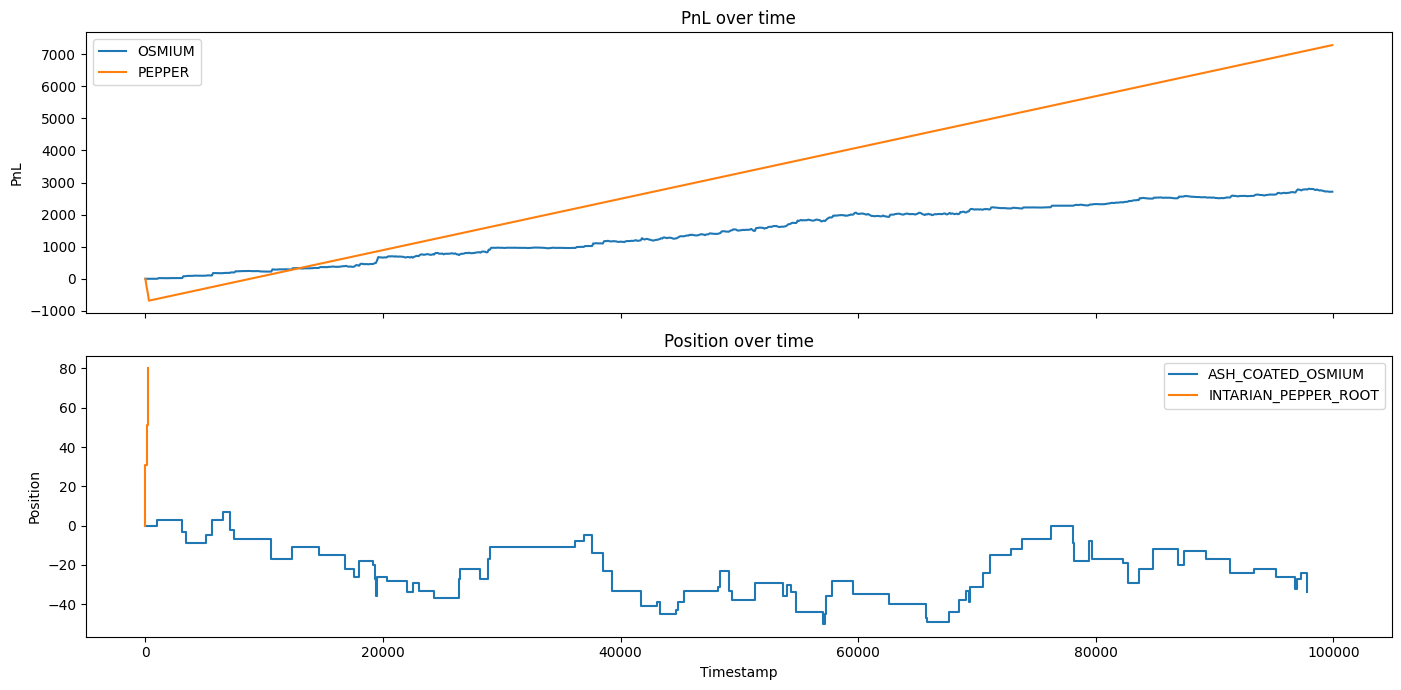

In [18]:
# Position + PnL over time (from submission .json)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for name, sub in [("OSMIUM", sub_osmium), ("PEPPER", sub_pepper)]:
    axes[0].plot(sub["timestamp"], sub["profit_and_loss"], label=name)
    
axes[0].set_title("PnL over time")
axes[0].legend()
axes[0].set_ylabel("PnL")

# Position from fills
for symbol in ["ASH_COATED_OSMIUM", "INTARIAN_PEPPER_ROOT"]:
    sym_fills = fills[fills["symbol"] == symbol].sort_values("timestamp")
    pos = 0
    timestamps = [0]
    positions = [0]
    for _, f in sym_fills.iterrows():
        pos += f["quantity"] if f["side"] == "BUY" else -f["quantity"]
        timestamps.append(f["timestamp"])
        positions.append(pos)
    axes[1].step(timestamps, positions, where="post", label=symbol)

axes[1].set_title("Position over time")
axes[1].legend()
axes[1].set_ylabel("Position")
axes[1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

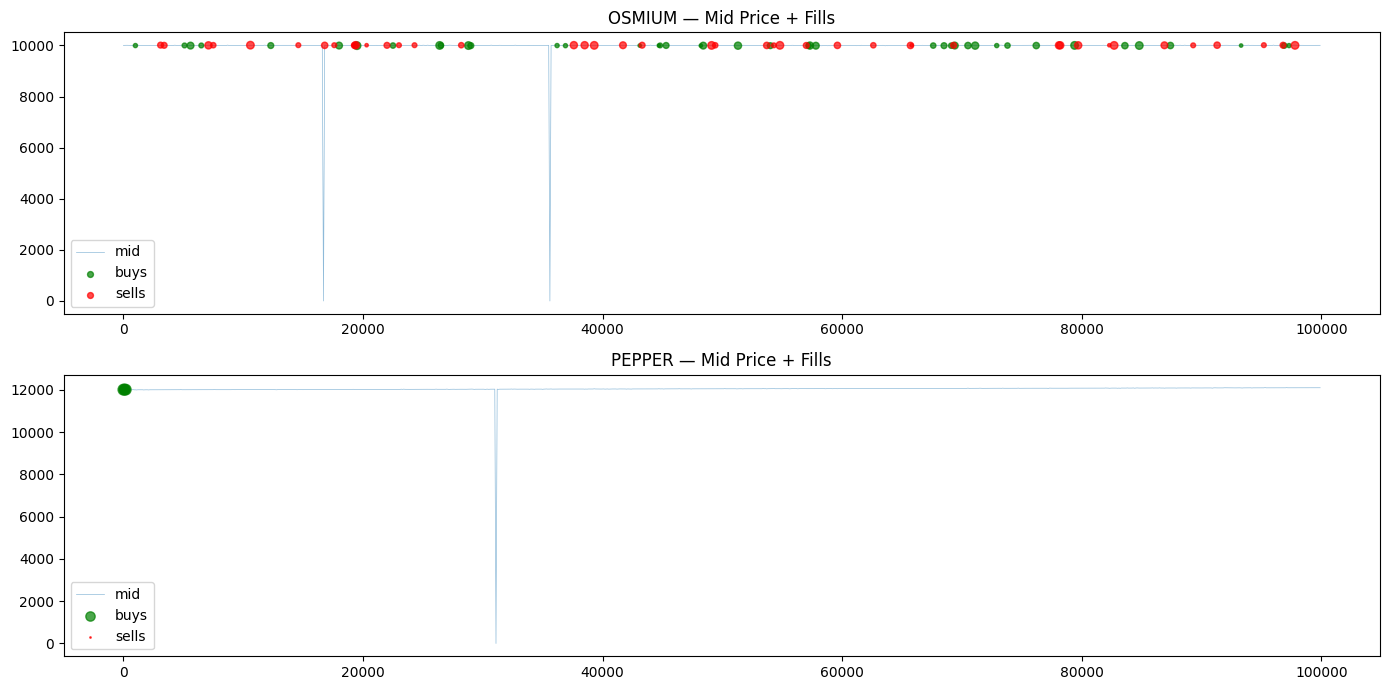

In [19]:
# Order book mid + fills overlay
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, (name, sub, symbol) in [(axes[0], ("OSMIUM", sub_osmium, "ASH_COATED_OSMIUM")),
                                  (axes[1], ("PEPPER", sub_pepper, "INTARIAN_PEPPER_ROOT"))]:
    ax.plot(sub["timestamp"], sub["mid_price"], linewidth=0.5, alpha=0.5, label="mid")
    
    sym_fills = fills[fills["symbol"] == symbol]
    buys = sym_fills[sym_fills["side"] == "BUY"]
    sells = sym_fills[sym_fills["side"] == "SELL"]
    
    ax.scatter(buys["timestamp"], buys["price"], color="green", s=buys["quantity"]*3, 
               alpha=0.7, label="buys", zorder=5)
    ax.scatter(sells["timestamp"], sells["price"], color="red", s=sells["quantity"]*3,
               alpha=0.7, label="sells", zorder=5)
    
    ax.set_title(f"{name} — Mid Price + Fills")
    ax.legend()

plt.tight_layout()
plt.show()

# Missed opportunity analysis

In [20]:
# Missed opportunity analysis for OSMIUM
# For each tick, what take edge was available vs what we captured?

osmium_acts = sub_osmium.copy()
osmium_fills = fills[fills["symbol"] == "ASH_COATED_OSMIUM"].copy()

# Compute wall_mid fair value per tick
bid_cols = [f"bid_price_{i}" for i in [1, 2, 3]]
ask_cols = [f"ask_price_{i}" for i in [1, 2, 3]]
osmium_acts["bid_wall"] = osmium_acts[bid_cols].min(axis=1)
osmium_acts["ask_wall"] = osmium_acts[ask_cols].max(axis=1)
osmium_acts["fair"] = (osmium_acts["bid_wall"] + osmium_acts["ask_wall"]) / 2

# Available edge per tick: any ask < fair (buy opp) or bid > fair (sell opp)
def edge_available(row):
    fair = row["fair"]
    if pd.isna(fair):
        return 0, 0
    buy_e, sell_e = 0, 0
    for i in [1, 2, 3]:
        ap, av = row[f"ask_price_{i}"], row[f"ask_volume_{i}"]
        if pd.notna(ap) and ap < fair:
            buy_e += av * (fair - ap)
        bp, bv = row[f"bid_price_{i}"], row[f"bid_volume_{i}"]
        if pd.notna(bp) and bp > fair:
            sell_e += bv * (bp - fair)
    return buy_e, sell_e

osmium_acts[["buy_opp", "sell_opp"]] = osmium_acts.apply(
    lambda r: pd.Series(edge_available(r)), axis=1
)

# Captured edge per fill: signed by side
fair_lookup = osmium_acts.set_index("timestamp")["fair"]
osmium_fills["fair"] = osmium_fills["timestamp"].map(fair_lookup)
osmium_fills["edge_signed"] = osmium_fills.apply(
    lambda r: (r["fair"] - r["price"]) * r["quantity"] if r["side"] == "BUY"
              else (r["price"] - r["fair"]) * r["quantity"], axis=1
)

available_buy = osmium_acts["buy_opp"].sum()
available_sell = osmium_acts["sell_opp"].sum()
captured = osmium_fills[osmium_fills["edge_signed"] > 0]["edge_signed"].sum()
adverse = osmium_fills[osmium_fills["edge_signed"] < 0]["edge_signed"].sum()

print(f"Buy-side opportunity (available):  {available_buy:>8.0f}")
print(f"Sell-side opportunity (available): {available_sell:>8.0f}")
print(f"Total available take edge:         {available_buy + available_sell:>8.0f}")
print()
print(f"Captured (positive edge fills):    {captured:>8.0f}")
print(f"Adverse (negative edge fills):     {adverse:>8.0f}")
print(f"Net captured:                      {captured + adverse:>8.0f}")
print()
total = available_buy + available_sell
if total > 0:
    print(f"Capture rate: {(captured + adverse) / total * 100:.1f}%")
print(f"Total OSMIUM PnL: {sub_osmium.groupby('day').last()['profit_and_loss'].sum():.0f}")

Buy-side opportunity (available):       234
Sell-side opportunity (available):      187
Total available take edge:              421

Captured (positive edge fills):        2704
Adverse (negative edge fills):            0
Net captured:                          2704

Capture rate: 642.2%
Total OSMIUM PnL: 2716


In [21]:
# Decompose OSMIUM PnL into take vs make
# A "take" fill happens when our order matches against an existing book level
# A "make" fill happens when a bot crosses to hit our resting order

# Approximation: fills at the BEST BID/ASK at that tick are likely takes (we crossed)
# Fills inside the spread are likely makes (bot crossed to us)

osmium_fills["best_bid"] = osmium_fills["timestamp"].map(
    osmium_acts.set_index("timestamp")["bid_price_1"]
)
osmium_fills["best_ask"] = osmium_fills["timestamp"].map(
    osmium_acts.set_index("timestamp")["ask_price_1"]
)

def classify(row):
    if row["side"] == "BUY":
        # Take if we bought at or above best_ask (we crossed to take)
        return "take" if row["price"] >= row["best_ask"] else "make"
    else:
        return "take" if row["price"] <= row["best_bid"] else "make"

osmium_fills["type"] = osmium_fills.apply(classify, axis=1)

print(osmium_fills.groupby(["type", "side"]).agg(
    count=("quantity", "size"),
    total_qty=("quantity", "sum"),
    avg_edge=("edge_signed", lambda x: x.sum() / max(1, len(x))),
    total_edge=("edge_signed", "sum"),
).round(2))

           count  total_qty  avg_edge  total_edge
type side                                        
make BUY      28        156     42.12      1179.5
     SELL     28        162     39.39      1103.0
take BUY      13         89     18.00       234.0
     SELL     15        117     12.47       187.0
